#  Module 1: Problem Definition & Dataset Understanding

## Business Problem

Sports analytics has become an important application of machine learning. Cricket teams, analysts, broadcasters, and fans often wish to estimate the probability of a team winning before a match starts.

The goal of this project is to build a predictive system that can estimate the likely winner of an IPL match using historical performance and contextual information available before the first ball is bowled.

## Target Variable

Target Column:

winner

The objective of the model is to correctly predict the winning team of each IPL match.

## Initial Input Features

The initial prediction model will use information available before the match begins, including:

- Season
- Team 1
- Team 2
- Venue
- City
- Toss Winner
- Toss Decision

Additional engineered features will be created in later modules.

In [214]:
# ==========================================================
# Module 1 : Import Required Libraries
# ==========================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

import warnings
warnings.filterwarnings("ignore")

In [215]:
matches = pd.read_csv("C:/Users/anujm/OneDrive/Documents/Desktop/CricketIQ/data/raw/matches.csv")
deliveries = pd.read_csv("C:/Users/anujm/OneDrive/Documents/Desktop/CricketIQ/data/raw/deliveries.csv")

In [216]:
print("Matches Shape :", matches.shape)
print("Deliveries Shape :", deliveries.shape)

matches.head()

Matches Shape : (1095, 20)
Deliveries Shape : (260920, 17)


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [217]:
matches["winner"].value_counts()

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Gujarat Titans                  28
Lucknow Super Giants            24
Punjab Kings                    24
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Royal Challengers Bengaluru      7
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Name: count, dtype: int64

# Module 2: Data Cleaning for Machine Learning

In [218]:
matches_ml = matches.copy()

print("Original dataset shape:", matches_ml.shape)

Original dataset shape: (1095, 20)


In [219]:
matches_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [220]:
matches_ml.columns.tolist()

['id',
 'season',
 'city',
 'date',
 'match_type',
 'player_of_match',
 'venue',
 'team1',
 'team2',
 'toss_winner',
 'toss_decision',
 'winner',
 'result',
 'result_margin',
 'target_runs',
 'target_overs',
 'super_over',
 'method',
 'umpire1',
 'umpire2']

In [221]:
missing_values = (
    matches_ml.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_values[missing_values > 0]

method             1074
city                 51
result_margin        19
winner                5
player_of_match       5
target_overs          3
target_runs           3
dtype: int64

In [222]:
season_mapping = {
    "2007/08": 2008,
    "2009": 2009,
    "2009/10": 2010,
    "2011": 2011,
    "2012": 2012,
    "2013": 2013,
    "2014": 2014,
    "2015": 2015,
    "2016": 2016,
    "2017": 2017,
    "2018": 2018,
    "2019": 2019,
    "2020/21": 2020,
    "2021": 2021,
    "2022": 2022,
    "2023": 2023,
    "2024": 2024
}

matches_ml["season"] = (
    matches_ml["season"]
    .astype(str)
    .str.strip()
    .replace(season_mapping)
    .astype(int)
)

In [223]:
sorted(matches_ml["season"].unique())

[2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2020,
 2021,
 2022,
 2023,
 2024]

In [224]:
matches_ml["date"] = pd.to_datetime(
    matches_ml["date"],
    errors="coerce"
)

In [225]:
matches_ml["date"].isnull().sum()

0

In [226]:
team_name_mapping = {
    "Delhi Daredevils": "Delhi Capitals",
    "Kings XI Punjab": "Punjab Kings",
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru",
    "Rising Pune Supergiant": "Rising Pune Supergiants"
}

In [227]:
team_columns = [
    "team1",
    "team2",
    "toss_winner",
    "winner"
]

for column in team_columns:
    matches_ml[column] = (
        matches_ml[column]
        .replace(team_name_mapping)
        .str.strip()
    )

In [228]:
sorted(matches_ml["team1"].dropna().unique())

['Chennai Super Kings',
 'Deccan Chargers',
 'Delhi Capitals',
 'Gujarat Lions',
 'Gujarat Titans',
 'Kochi Tuskers Kerala',
 'Kolkata Knight Riders',
 'Lucknow Super Giants',
 'Mumbai Indians',
 'Pune Warriors',
 'Punjab Kings',
 'Rajasthan Royals',
 'Rising Pune Supergiants',
 'Royal Challengers Bengaluru',
 'Sunrisers Hyderabad']

In [229]:
matches_ml["toss_decision"] = (
    matches_ml["toss_decision"]
    .astype(str)
    .str.strip()
    .str.lower()
)

In [230]:
matches_ml["toss_decision"].value_counts(dropna=False)

toss_decision
field    704
bat      391
Name: count, dtype: int64

In [231]:
matches_ml["result"] = (
    matches_ml["result"]
    .astype(str)
    .str.strip()
    .str.lower()
)

In [232]:
matches_ml["result"].value_counts(dropna=False)

result
wickets      578
runs         498
tie           14
no result      5
Name: count, dtype: int64

In [233]:
print(
    "Matches without winner:",
    matches_ml["winner"].isnull().sum()
)

Matches without winner: 5


In [234]:
matches_ml = matches_ml[
    matches_ml["winner"].notna()
].copy()

matches_ml = matches_ml[
    matches_ml["result"] != "no result"
].copy()

matches_ml.reset_index(drop=True, inplace=True)

print("Shape after removing no-result matches:", matches_ml.shape)
print("Missing winner values:", matches_ml["winner"].isnull().sum())

Shape after removing no-result matches: (1090, 20)
Missing winner values: 0


In [235]:
matches_ml.loc[
    matches_ml["city"].isnull(),
    ["season", "venue", "city"]
].drop_duplicates()

venue_city_mapping = {
    "Dubai International Cricket Stadium": "Dubai",
    "Sharjah Cricket Stadium": "Sharjah",
    "Sheikh Zayed Stadium": "Abu Dhabi"
}

matches_ml["city"] = matches_ml["city"].fillna(
    matches_ml["venue"].map(venue_city_mapping)
)

matches_ml["city"] = matches_ml["city"].fillna("Unknown")

matches_ml["city"].isnull().sum()

0

In [238]:
venue_mapping = {
    "M Chinnaswamy Stadium": "M. Chinnaswamy Stadium",
    "Punjab Cricket Association IS Bindra Stadium, Mohali":
        "Punjab Cricket Association IS Bindra Stadium",
    "Punjab Cricket Association Stadium, Mohali":
        "Punjab Cricket Association IS Bindra Stadium",
    "MA Chidambaram Stadium, Chepauk":
        "MA Chidambaram Stadium",
    "MA Chidambaram Stadium, Chepauk, Chennai":
        "MA Chidambaram Stadium",
    "Wankhede Stadium, Mumbai":
        "Wankhede Stadium",
    "Arun Jaitley Stadium, Delhi":
        "Arun Jaitley Stadium",
    "Feroz Shah Kotla":
         "Arun Jaitley Stadium",
    "Arun Jaitely Stadium":
         "Arun Jaitley Stadium",
    "Rajiv Gandhi International Stadium, Uppal":
        "Rajiv Gandhi International Stadium",
    "Rajiv Gandhi International Stadium, Uppal, Hyderabad":
        "Rajiv Gandhi International Stadium",
    "Eden Gardens, Kolkata":
        "Eden Gardens",
    "Brabourne Stadium, Mumbai":
        "Brabourne Stadium",
    "Dr DY Patil Sports Academy, Mumbai":
        "Dr DY Patil Sports Academy",
    "Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam":
         "Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium",
    "Himachal Pradesh Cricket Association Stadium, Dharamsala":
         "Himachal Pradesh Cricket Association Stadium",
    "M Chinnaswamy Stadium, Bengaluru":
         "M. Chinnaswamy Stadium",
    "M.Chinnaswamy Stadium":
         "M. Chinnaswamy Stadium",
    "Maharashtra Cricket Association Stadium, Pune":
          "Maharashtra Cricket Association Stadium",
    "Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh":
           "Punjab Cricket Association IS Bindra Stadium",
    "Sawai Mansingh Stadium, Jaipur":
           "Sawai Mansingh Stadium",
    "Subrata Roy Sahara Stadium":
           "Maharashtra Cricket Association Stadium",
    "Zayed Cricket Stadium, Abu Dhabi":
           "Sheikh Zayed Stadium"
            
}

matches_ml["venue"] = (
    matches_ml["venue"]
    .replace(venue_mapping)
    .str.strip()
)

sorted(matches_ml["venue"].dropna().unique())

['Arun Jaitley Stadium',
 'Barabati Stadium',
 'Barsapara Cricket Stadium, Guwahati',
 'Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow',
 'Brabourne Stadium',
 'Buffalo Park',
 'De Beers Diamond Oval',
 'Dr DY Patil Sports Academy',
 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium',
 'Dubai International Cricket Stadium',
 'Eden Gardens',
 'Green Park',
 'Himachal Pradesh Cricket Association Stadium',
 'Holkar Cricket Stadium',
 'JSCA International Stadium Complex',
 'Kingsmead',
 'M. Chinnaswamy Stadium',
 'MA Chidambaram Stadium',
 'Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur',
 'Maharashtra Cricket Association Stadium',
 'Narendra Modi Stadium, Ahmedabad',
 'Nehru Stadium',
 'New Wanderers Stadium',
 'Newlands',
 'OUTsurance Oval',
 'Punjab Cricket Association IS Bindra Stadium',
 'Rajiv Gandhi International Stadium',
 'Sardar Patel Stadium, Motera',
 'Saurashtra Cricket Association Stadium',
 'Sawai Mansingh Stadium',
 'Shaheed Vee

In [239]:
invalid_winners = matches_ml[
    ~(
        (matches_ml["winner"] == matches_ml["team1"]) |
        (matches_ml["winner"] == matches_ml["team2"])
    )
]

invalid_winners[
    ["season", "team1", "team2", "winner"]
]

print("Invalid winner records:", len(invalid_winners))

Invalid winner records: 0


In [240]:
matches_ml["id"].duplicated().sum()

matches_ml.duplicated().sum()

matches_ml.drop_duplicates(inplace=True)

matches_ml = matches_ml.sort_values(
    by=["date", "id"]
).reset_index(drop=True)

matches_ml[
    ["id", "season", "date", "team1", "team2", "winner"]
].head()

,id,season,date,team1,team2,winner
0,335982,2008,2008-04-18,Royal Challengers Bengaluru,Kolkata Knight Riders,Kolkata Knight Riders
1,335983,2008,2008-04-19,Punjab Kings,Chennai Super Kings,Chennai Super Kings
2,335984,2008,2008-04-19,Delhi Capitals,Rajasthan Royals,Delhi Capitals
3,335985,2008,2008-04-20,Mumbai Indians,Royal Challengers Bengaluru,Royal Challengers Bengaluru
4,335986,2008,2008-04-20,Kolkata Knight Riders,Deccan Chargers,Kolkata Knight Riders


In [241]:
matches_ml[
    ["id", "season", "date", "team1", "team2", "winner"]
].tail()

,id,season,date,team1,team2,winner
1085,1426307,2024,2024-05-19,Punjab Kings,Sunrisers Hyderabad,Sunrisers Hyderabad
1086,1426309,2024,2024-05-21,Sunrisers Hyderabad,Kolkata Knight Riders,Kolkata Knight Riders
1087,1426310,2024,2024-05-22,Royal Challengers Bengaluru,Rajasthan Royals,Rajasthan Royals
1088,1426311,2024,2024-05-24,Sunrisers Hyderabad,Rajasthan Royals,Sunrisers Hyderabad
1089,1426312,2024,2024-05-26,Sunrisers Hyderabad,Kolkata Knight Riders,Kolkata Knight Riders


In [242]:
matches_ml["match_number"] = np.arange(
    1,
    len(matches_ml) + 1
)

matches_ml[
    ["match_number", "id", "season", "date"]
].head()

,match_number,id,season,date
0,1,335982,2008,2008-04-18
1,2,335983,2008,2008-04-19
2,3,335984,2008,2008-04-19
3,4,335985,2008,2008-04-20
4,5,335986,2008,2008-04-20


In [243]:
ml_columns = [
    "id",
    "match_number",
    "season",
    "date",
    "city",
    "venue",
    "team1",
    "team2",
    "toss_winner",
    "toss_decision",
    "winner"
]

matches_ml = matches_ml[ml_columns].copy()

print("Cleaned dataset shape:", matches_ml.shape)
print()
print("Season range:")
print(matches_ml["season"].min(), "to", matches_ml["season"].max())
print()
print("Date range:")
print(matches_ml["date"].min(), "to", matches_ml["date"].max())
print()
print("Missing values:")
print(matches_ml.isnull().sum())

Cleaned dataset shape: (1090, 11)

Season range:
2008 to 2024

Date range:
2008-04-18 00:00:00 to 2024-05-26 00:00:00

Missing values:
id               0
match_number     0
season           0
date             0
city             0
venue            0
team1            0
team2            0
toss_winner      0
toss_decision    0
winner           0
dtype: int64


In [308]:
print("Number of teams:", matches_ml["team1"].nunique())
print("Number of venues:", matches_ml["venue"].nunique())
print("Number of cities:", matches_ml["city"].nunique())

Number of teams: 15
Number of venues: 37
Number of cities: 36


In [245]:
matches_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1090 entries, 0 to 1089
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             1090 non-null   int64         
 1   match_number   1090 non-null   int32         
 2   season         1090 non-null   int32         
 3   date           1090 non-null   datetime64[ns]
 4   city           1090 non-null   object        
 5   venue          1090 non-null   object        
 6   team1          1090 non-null   object        
 7   team2          1090 non-null   object        
 8   toss_winner    1090 non-null   object        
 9   toss_decision  1090 non-null   object        
 10  winner         1090 non-null   object        
dtypes: datetime64[ns](1), int32(2), int64(1), object(7)
memory usage: 85.3+ KB


In [246]:
matches_ml.head()

,id,match_number,season,date,city,venue,team1,team2,toss_winner,toss_decision,winner
0,335982,1,2008,2008-04-18,Bangalore,M. Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,field,Kolkata Knight Riders
1,335983,2,2008,2008-04-19,Chandigarh,Punjab Cricket Association IS Bindra Stadium,Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings
2,335984,3,2008,2008-04-19,Delhi,Arun Jaitley Stadium,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,Delhi Capitals
3,335985,4,2008,2008-04-20,Mumbai,Wankhede Stadium,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,bat,Royal Challengers Bengaluru
4,335986,5,2008,2008-04-20,Kolkata,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders


# Module 3: Exploratory Analysis for Machine Learning

In [247]:
matches_ml.to_csv(
    "ipl_matches_ml_cleaned.csv",
    index=False
)

print("Cleaned ML dataset saved successfully.")

Cleaned ML dataset saved successfully.


In [248]:
matches_ml = pd.read_csv(
    "ipl_matches_ml_cleaned.csv",
    parse_dates=["date"]
)

matches_ml.head()

,id,match_number,season,date,city,venue,team1,team2,toss_winner,toss_decision,winner
0,335982,1,2008,2008-04-18,Bangalore,M. Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,field,Kolkata Knight Riders
1,335983,2,2008,2008-04-19,Chandigarh,Punjab Cricket Association IS Bindra Stadium,Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings
2,335984,3,2008,2008-04-19,Delhi,Arun Jaitley Stadium,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,Delhi Capitals
3,335985,4,2008,2008-04-20,Mumbai,Wankhede Stadium,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,bat,Royal Challengers Bengaluru
4,335986,5,2008,2008-04-20,Kolkata,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders


In [249]:
print("Dataset shape:", matches_ml.shape)

Dataset shape: (1090, 11)


In [250]:
matches_ml["team1_win"] = (
    matches_ml["winner"] == matches_ml["team1"]
).astype(int)

matches_ml[
    ["team1", "team2", "winner", "team1_win"]
].head(10)

,team1,team2,winner,team1_win
0,Royal Challengers Bengaluru,Kolkata Knight Riders,Kolkata Knight Riders,0
1,Punjab Kings,Chennai Super Kings,Chennai Super Kings,0
2,Delhi Capitals,Rajasthan Royals,Delhi Capitals,1
3,Mumbai Indians,Royal Challengers Bengaluru,Royal Challengers Bengaluru,0
4,Kolkata Knight Riders,Deccan Chargers,Kolkata Knight Riders,1
5,Rajasthan Royals,Punjab Kings,Rajasthan Royals,1
6,Deccan Chargers,Delhi Capitals,Delhi Capitals,0
7,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,1
8,Deccan Chargers,Rajasthan Royals,Rajasthan Royals,0
9,Punjab Kings,Mumbai Indians,Punjab Kings,1


In [251]:
invalid_target_rows = matches_ml[
    ~(
        ((matches_ml["team1_win"] == 1) &
         (matches_ml["winner"] == matches_ml["team1"])) |
        
        ((matches_ml["team1_win"] == 0) &
         (matches_ml["winner"] == matches_ml["team2"]))
    )
]

print("Invalid target rows:", len(invalid_target_rows))

Invalid target rows: 0


In [252]:
target_distribution = (
    matches_ml["team1_win"]
    .value_counts()
    .sort_index()
)

target_distribution

team1_win
0    535
1    555
Name: count, dtype: int64

In [253]:
target_percentage = (
    matches_ml["team1_win"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

target_percentage

team1_win
0    49.08
1    50.92
Name: proportion, dtype: float64

In [254]:
target_summary = pd.DataFrame({
    "Outcome": ["Team 2 Won", "Team 1 Won"],
    "Matches": [
        target_distribution.get(0, 0),
        target_distribution.get(1, 0)
    ],
    "Percentage": [
        target_percentage.get(0, 0),
        target_percentage.get(1, 0)
    ]
})

target_summary

,Outcome,Matches,Percentage
0,Team 2 Won,535,49.08
1,Team 1 Won,555,50.92


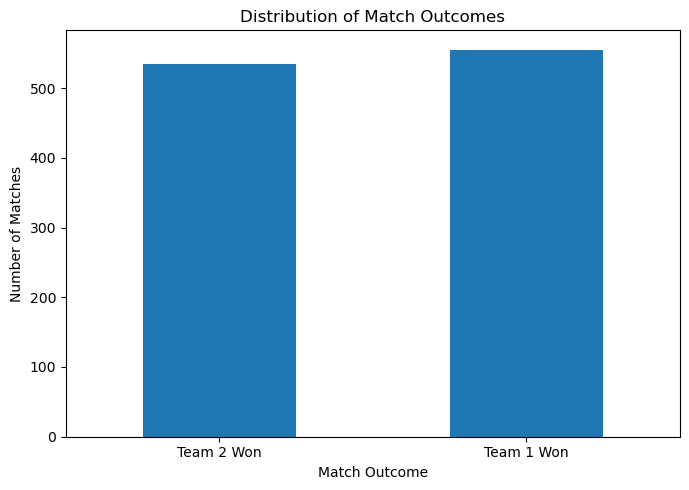

In [255]:
plt.figure(figsize=(7, 5))

target_summary.set_index("Outcome")["Matches"].plot(
    kind="bar"
)

plt.title("Distribution of Match Outcomes")
plt.xlabel("Match Outcome")
plt.ylabel("Number of Matches")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [256]:
matches_ml["team1_won_toss"] = (
    matches_ml["toss_winner"] == matches_ml["team1"]
).astype(int)

team1_toss_summary = pd.crosstab(
    matches_ml["team1_won_toss"],
    matches_ml["team1_win"],
    margins=True
)

team1_toss_summary

team1_toss_summary = pd.crosstab(
    matches_ml["team1_won_toss"].map({
        0: "Team 2 won toss",
        1: "Team 1 won toss"
    }),
    matches_ml["team1_win"].map({
        0: "Team 2 won match",
        1: "Team 1 won match"
    })
)

team1_toss_summary

team1_win,Team 1 won match,Team 2 won match
team1_won_toss,,
Team 1 won toss,221,202
Team 2 won toss,334,333


In [257]:
matches_per_season = (
    matches_ml.groupby("season")
    .size()
    .reset_index(name="matches")
    .sort_values("season")
)

matches_per_season

,season,matches
0,2008,58
1,2009,57
2,2010,60
3,2011,72
4,2012,74
5,2013,76
6,2014,60
7,2015,57
8,2016,60
9,2017,59


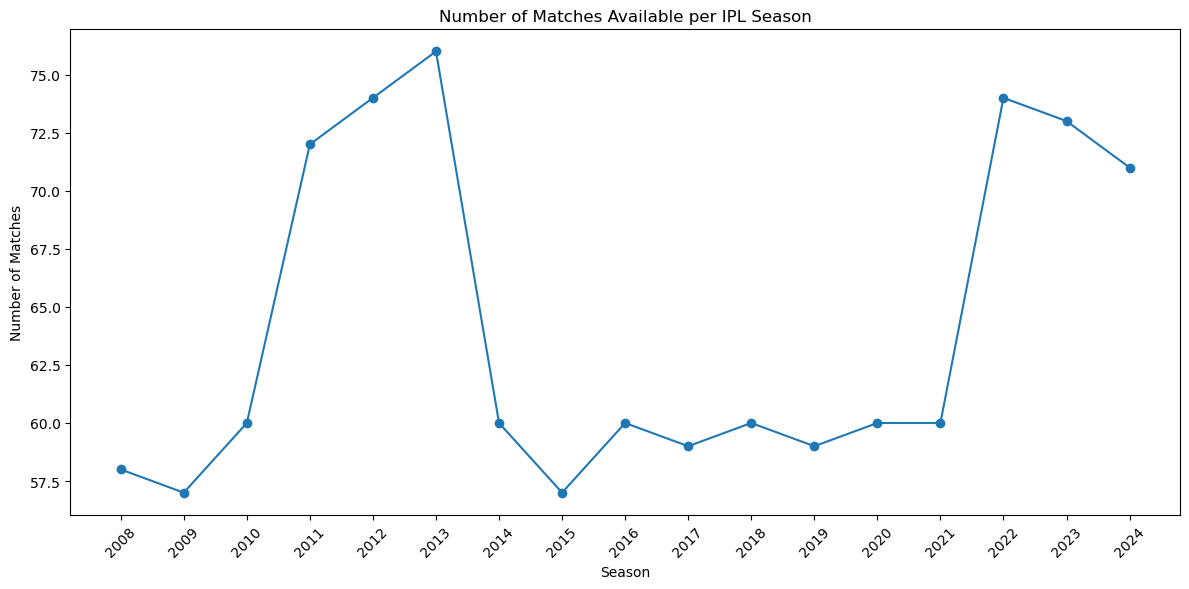

In [258]:
plt.figure(figsize=(12, 6))

plt.plot(
    matches_per_season["season"],
    matches_per_season["matches"],
    marker="o"
)

plt.title("Number of Matches Available per IPL Season")
plt.xlabel("Season")
plt.ylabel("Number of Matches")
plt.xticks(
    matches_per_season["season"],
    rotation=45
)
plt.tight_layout()
plt.show()

In [259]:
team1_matches = (
    matches_ml["team1"]
    .value_counts()
    .rename("team1_matches")
)

team2_matches = (
    matches_ml["team2"]
    .value_counts()
    .rename("team2_matches")
)

team_representation = pd.concat(
    [team1_matches, team2_matches],
    axis=1
).fillna(0)

team_representation["total_matches"] = (
    team_representation["team1_matches"] +
    team_representation["team2_matches"]
).astype(int)

team_representation = (
    team_representation
    .sort_values("total_matches", ascending=False)
)

team_representation

,team1_matches,team2_matches,total_matches
Mumbai Indians,123,138,261
Royal Challengers Bengaluru,141,111,252
Kolkata Knight Riders,121,130,251
Delhi Capitals,125,125,250
Punjab Kings,123,123,246
Chennai Super Kings,128,109,237
Rajasthan Royals,101,118,219
Sunrisers Hyderabad,86,96,182
Deccan Chargers,39,36,75
Pune Warriors,23,22,45


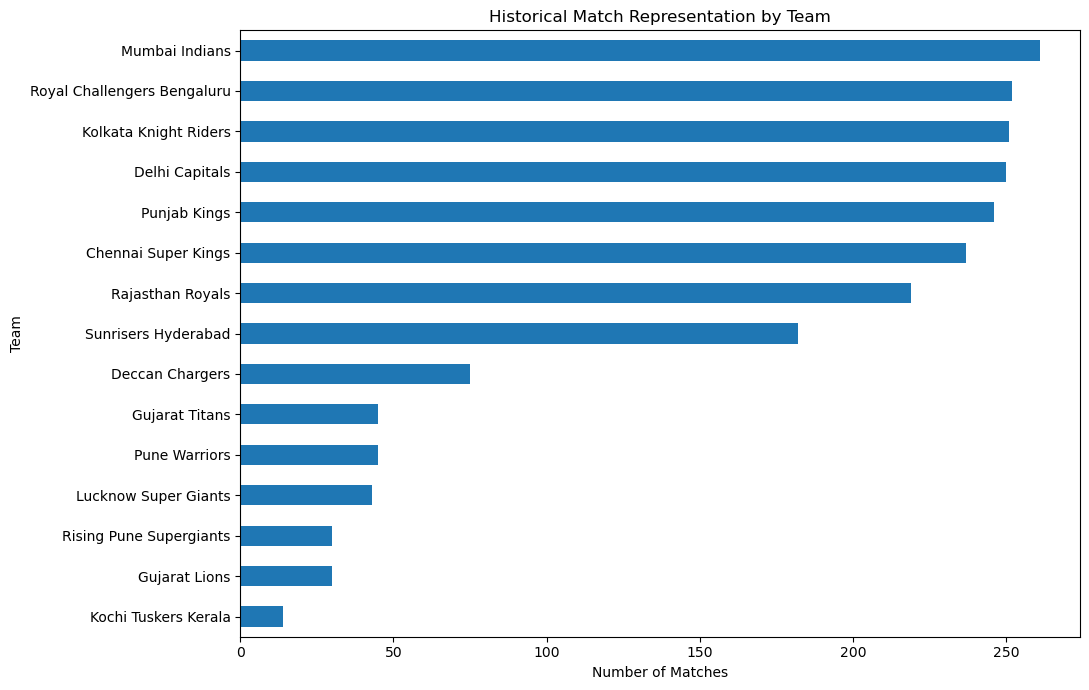

In [260]:
plt.figure(figsize=(11, 7))

team_representation["total_matches"].sort_values().plot(
    kind="barh"
)

plt.title("Historical Match Representation by Team")
plt.xlabel("Number of Matches")
plt.ylabel("Team")
plt.tight_layout()
plt.show()

In [261]:
current_teams = [
    "Chennai Super Kings",
    "Delhi Capitals",
    "Gujarat Titans",
    "Kolkata Knight Riders",
    "Lucknow Super Giants",
    "Mumbai Indians",
    "Punjab Kings",
    "Rajasthan Royals",
    "Royal Challengers Bengaluru",
    "Sunrisers Hyderabad"
]

all_teams = sorted(
    set(matches_ml["team1"]).union(
        set(matches_ml["team2"])
    )
)

team_status = pd.DataFrame({
    "team": all_teams
})

team_status["status"] = np.where(
    team_status["team"].isin(current_teams),
    "Current Team",
    "Inactive Team"
)

team_status

,team,status
0,Chennai Super Kings,Current Team
1,Deccan Chargers,Inactive Team
2,Delhi Capitals,Current Team
3,Gujarat Lions,Inactive Team
4,Gujarat Titans,Current Team
5,Kochi Tuskers Kerala,Inactive Team
6,Kolkata Knight Riders,Current Team
7,Lucknow Super Giants,Current Team
8,Mumbai Indians,Current Team
9,Pune Warriors,Inactive Team


In [262]:
venue_frequency = (
    matches_ml["venue"]
    .value_counts()
    .reset_index()
)

venue_frequency.columns = ["venue", "matches"]

venue_frequency.head(15)

,venue,matches
0,Wankhede Stadium,118
1,Eden Gardens,93
2,M. Chinnaswamy Stadium,91
3,Arun Jaitley Stadium,89
4,MA Chidambaram Stadium,85
5,Rajiv Gandhi International Stadium,77
6,Punjab Cricket Association IS Bindra Stadium,61
7,Sawai Mansingh Stadium,57
8,Maharashtra Cricket Association Stadium,51
9,Dubai International Cricket Stadium,46


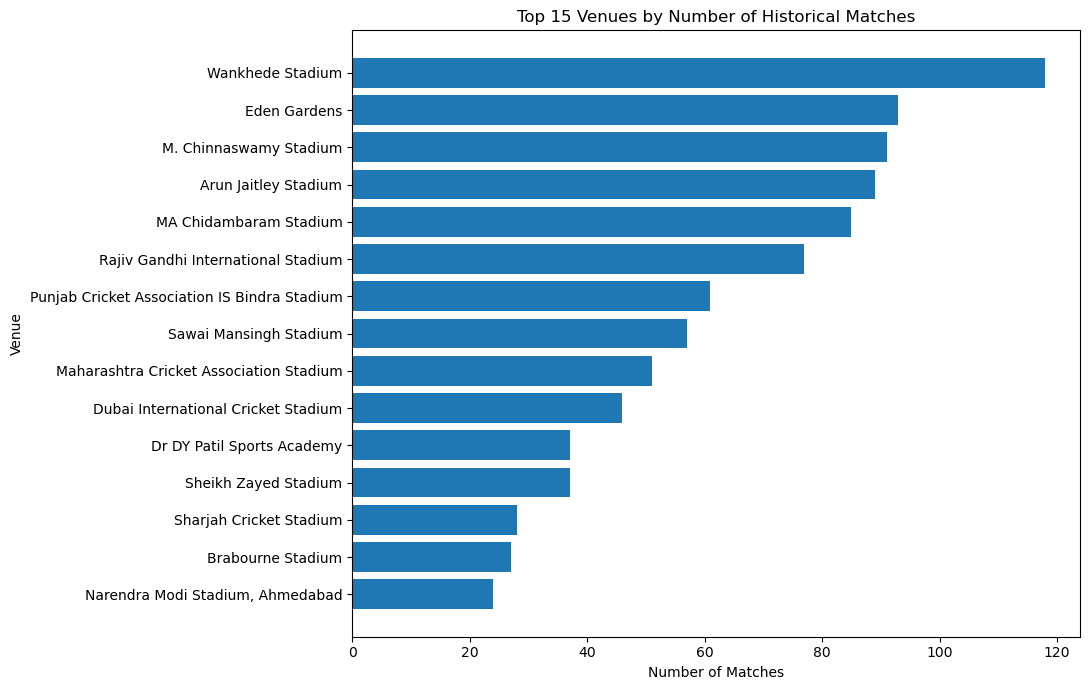

In [263]:
top_venues = venue_frequency.head(15)

plt.figure(figsize=(11, 7))

plt.barh(
    top_venues["venue"][::-1],
    top_venues["matches"][::-1]
)

plt.title("Top 15 Venues by Number of Historical Matches")
plt.xlabel("Number of Matches")
plt.ylabel("Venue")
plt.tight_layout()
plt.show()

In [264]:
toss_decision_summary = (
    matches_ml["toss_decision"]
    .value_counts()
    .reset_index()
)

toss_decision_summary.columns = [
    "toss_decision",
    "matches"
]

toss_decision_summary

,toss_decision,matches
0,field,700
1,bat,390


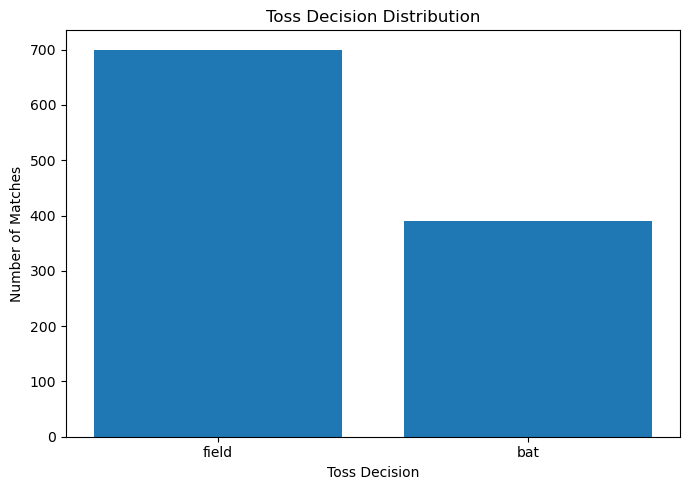

In [265]:
plt.figure(figsize=(7, 5))

plt.bar(
    toss_decision_summary["toss_decision"],
    toss_decision_summary["matches"]
)

plt.title("Toss Decision Distribution")
plt.xlabel("Toss Decision")
plt.ylabel("Number of Matches")
plt.tight_layout()
plt.show()

In [266]:
season_toss_decision = pd.crosstab(
    matches_ml["season"],
    matches_ml["toss_decision"],
    normalize="index"
).mul(100)

season_toss_decision.round(0)

toss_decision,bat,field
season,,
2008,45.0,55.0
2009,61.0,39.0
2010,65.0,35.0
2011,33.0,67.0
2012,50.0,50.0
2013,59.0,41.0
2014,32.0,68.0
2015,44.0,56.0
2016,18.0,82.0


In [267]:
matches_ml["toss_winner_won_match"] = (
    matches_ml["toss_winner"] == matches_ml["winner"]
).astype(int)

toss_conversion_rate = (
    matches_ml["toss_winner_won_match"]
    .mean() * 100
)

print(
    f"Toss winner also won the match in "
    f"{toss_conversion_rate:.2f}% of matches."
)

Toss winner also won the match in 50.83% of matches.


In [268]:
toss_match_summary = (
    matches_ml["toss_winner_won_match"]
    .value_counts()
    .rename(index={
        0: "Toss winner lost match",
        1: "Toss winner won match"
    })
    .reset_index()
)

toss_match_summary.columns = [
    "outcome",
    "matches"
]

toss_match_summary

,outcome,matches
0,Toss winner won match,554
1,Toss winner lost match,536


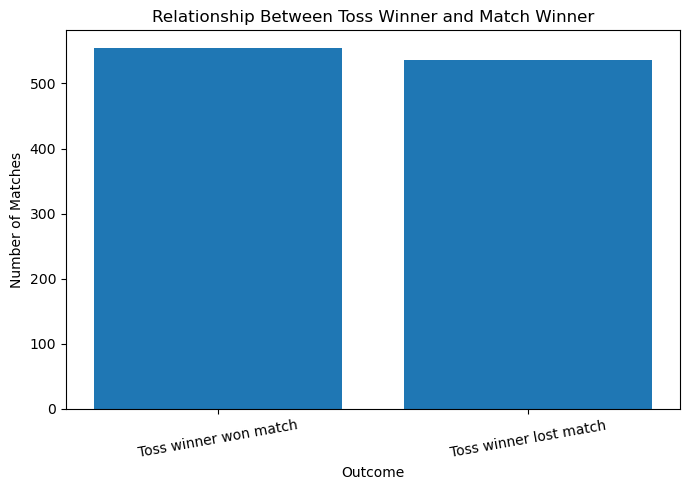

In [269]:
plt.figure(figsize=(7, 5))

plt.bar(
    toss_match_summary["outcome"],
    toss_match_summary["matches"]
)

plt.title("Relationship Between Toss Winner and Match Winner")
plt.xlabel("Outcome")
plt.ylabel("Number of Matches")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

In [270]:
toss_decision_impact = (
    matches_ml.groupby("toss_decision")
    ["toss_winner_won_match"]
    .agg(["count", "mean"])
    .reset_index()
)

toss_decision_impact["win_percentage"] = (
    toss_decision_impact["mean"] * 100
).round(2)

toss_decision_impact = toss_decision_impact[
    ["toss_decision", "count", "win_percentage"]
]

toss_decision_impact

,toss_decision,count,win_percentage
0,bat,390,45.38
1,field,700,53.86


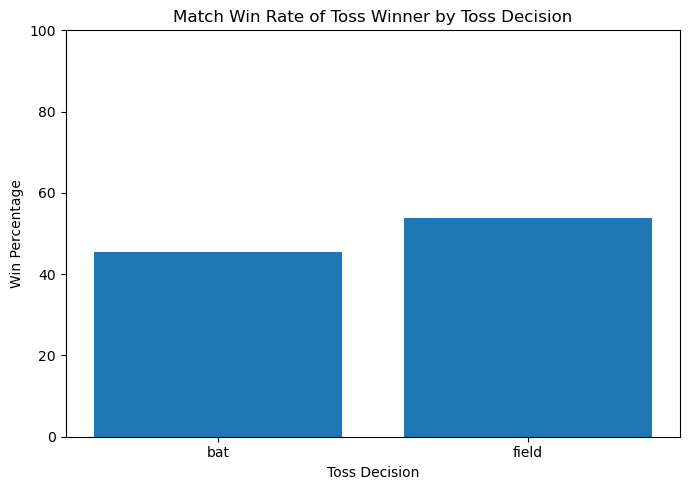

In [271]:
plt.figure(figsize=(7, 5))

plt.bar(
    toss_decision_impact["toss_decision"],
    toss_decision_impact["win_percentage"]
)

plt.title("Match Win Rate of Toss Winner by Toss Decision")
plt.xlabel("Toss Decision")
plt.ylabel("Win Percentage")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [272]:
team1_win_by_season = (
    matches_ml.groupby("season")["team1_win"]
    .agg(["count", "mean"])
    .reset_index()
)

team1_win_by_season["team1_win_percentage"] = (
    team1_win_by_season["mean"] * 100
).round(2)

team1_win_by_season = team1_win_by_season[
    ["season", "count", "team1_win_percentage"]
]

team1_win_by_season

,season,count,team1_win_percentage
0,2008,58,51.72
1,2009,57,54.39
2,2010,60,55.00
3,2011,72,54.17
4,2012,74,44.59
5,2013,76,71.05
6,2014,60,46.67
7,2015,57,54.39
8,2016,60,46.67
9,2017,59,54.24


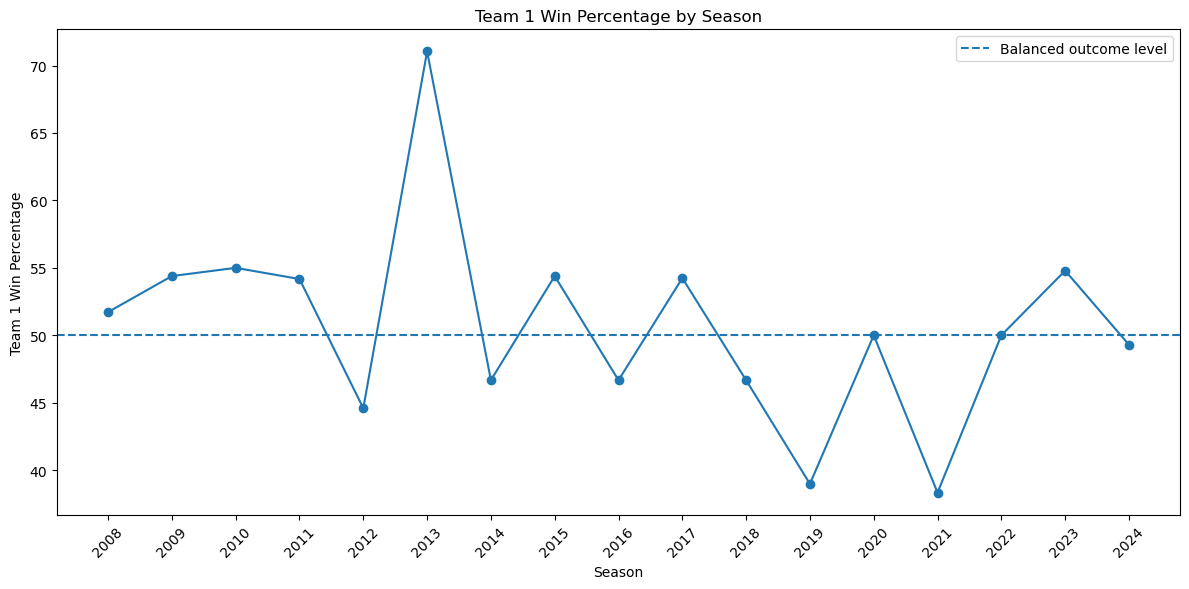

In [273]:
plt.figure(figsize=(12, 6))

plt.plot(
    team1_win_by_season["season"],
    team1_win_by_season["team1_win_percentage"],
    marker="o"
)

plt.axhline(
    y=50,
    linestyle="--",
    label="Balanced outcome level"
)

plt.title("Team 1 Win Percentage by Season")
plt.xlabel("Season")
plt.ylabel("Team 1 Win Percentage")
plt.xticks(
    team1_win_by_season["season"],
    rotation=45
)
plt.legend()
plt.tight_layout()
plt.show()

In [274]:
matches_ml.isnull().sum()

id                       0
match_number             0
season                   0
date                     0
city                     0
venue                    0
team1                    0
team2                    0
toss_winner              0
toss_decision            0
winner                   0
team1_win                0
team1_won_toss           0
toss_winner_won_match    0
dtype: int64

In [275]:
modelling_columns = [
    "season",
    "date",
    "city",
    "venue",
    "team1",
    "team2",
    "toss_winner",
    "toss_decision",
    "team1_win"
]

matches_ml[modelling_columns].isnull().sum()

season           0
date             0
city             0
venue            0
team1            0
team2            0
toss_winner      0
toss_decision    0
team1_win        0
dtype: int64

In [276]:
modelling_columns = [
    "season",
    "date",
    "city",
    "venue",
    "team1",
    "team2",
    "toss_winner",
    "toss_decision",
    "team1_win"
]

matches_ml[modelling_columns].isnull().sum()

season           0
date             0
city             0
venue            0
team1            0
team2            0
toss_winner      0
toss_decision    0
team1_win        0
dtype: int64

In [277]:
base_model_columns = [
    "id",
    "match_number",
    "season",
    "date",
    "city",
    "venue",
    "team1",
    "team2",
    "toss_winner",
    "toss_decision",
    "team1_won_toss",
    "team1_win"
]

model_base = matches_ml[
    base_model_columns
].copy()

model_base.head()

,id,match_number,season,date,city,venue,team1,team2,toss_winner,toss_decision,team1_won_toss,team1_win
0,335982,1,2008,2008-04-18,Bangalore,M. Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,field,1,0
1,335983,2,2008,2008-04-19,Chandigarh,Punjab Cricket Association IS Bindra Stadium,Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,0,0
2,335984,3,2008,2008-04-19,Delhi,Arun Jaitley Stadium,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,0,1
3,335985,4,2008,2008-04-20,Mumbai,Wankhede Stadium,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,bat,1,0
4,335986,5,2008,2008-04-20,Kolkata,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,0,1


In [278]:
model_base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1090 entries, 0 to 1089
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id              1090 non-null   int64         
 1   match_number    1090 non-null   int64         
 2   season          1090 non-null   int64         
 3   date            1090 non-null   datetime64[ns]
 4   city            1090 non-null   object        
 5   venue           1090 non-null   object        
 6   team1           1090 non-null   object        
 7   team2           1090 non-null   object        
 8   toss_winner     1090 non-null   object        
 9   toss_decision   1090 non-null   object        
 10  team1_won_toss  1090 non-null   int32         
 11  team1_win       1090 non-null   int32         
dtypes: datetime64[ns](1), int32(2), int64(3), object(6)
memory usage: 93.8+ KB


In [279]:
model_base.to_csv(
    "ipl_ml_base_dataset.csv",
    index=False
)

print("Base ML dataset saved successfully.")

Base ML dataset saved successfully.


# Module 4: Feature Engineering

In [280]:
from collections import defaultdict, deque
import numpy as np
import pandas as pd

model_base = model_base.sort_values(
    ["date", "id"]
).reset_index(drop=True)

# Historical records
recent_results = defaultdict(lambda: deque(maxlen=5))

h2h_matches = defaultdict(int)
h2h_wins = defaultdict(lambda: defaultdict(int))

venue_matches = defaultdict(int)
venue_wins = defaultdict(int)

season_matches = defaultdict(int)
season_wins = defaultdict(int)

team_matches = defaultdict(int)

# Elo ratings
elo_rating = defaultdict(lambda: 1500)

def safe_rate(wins, matches):
    return wins / matches if matches else 0.5

def expected_score(rating_a, rating_b):
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))

feature_rows = []

for _, row in model_base.iterrows():

    team1 = row["team1"]
    team2 = row["team2"]
    season = row["season"]
    venue = row["venue"]

    winner = team1 if row["team1_win"] == 1 else team2
    h2h_key = tuple(sorted([team1, team2]))

    # Elo ratings before the current match
    team1_elo = elo_rating[team1]
    team2_elo = elo_rating[team2]

    features = {
        "team1_elo": team1_elo,
        "team2_elo": team2_elo,

        "team1_recent_form":
            np.mean(recent_results[team1])
            if recent_results[team1] else 0.5,

        "team2_recent_form":
            np.mean(recent_results[team2])
            if recent_results[team2] else 0.5,

        "team1_h2h_win_rate":
            safe_rate(
                h2h_wins[h2h_key][team1],
                h2h_matches[h2h_key]
            ),

        "team2_h2h_win_rate":
            safe_rate(
                h2h_wins[h2h_key][team2],
                h2h_matches[h2h_key]
            ),

        "team1_venue_win_rate":
            safe_rate(
                venue_wins[(team1, venue)],
                venue_matches[(team1, venue)]
            ),

        "team2_venue_win_rate":
            safe_rate(
                venue_wins[(team2, venue)],
                venue_matches[(team2, venue)]
            ),

        "team1_season_win_rate":
            safe_rate(
                season_wins[(season, team1)],
                season_matches[(season, team1)]
            ),

        "team2_season_win_rate":
            safe_rate(
                season_wins[(season, team2)],
                season_matches[(season, team2)]
            ),

        "team1_matches_played": team_matches[team1],
        "team2_matches_played": team_matches[team2]
    }

    feature_rows.append(features)

    # Update historical records after creating features
    for team in [team1, team2]:
        team_matches[team] += 1
        season_matches[(season, team)] += 1
        venue_matches[(team, venue)] += 1

    season_wins[(season, winner)] += 1
    venue_wins[(winner, venue)] += 1

    recent_results[team1].append(int(winner == team1))
    recent_results[team2].append(int(winner == team2))

    h2h_matches[h2h_key] += 1
    h2h_wins[h2h_key][winner] += 1

    # Elo update after the match
    expected_team1 = expected_score(team1_elo, team2_elo)
    expected_team2 = expected_score(team2_elo, team1_elo)

    actual_team1 = int(winner == team1)
    actual_team2 = int(winner == team2)

    K = 20

    elo_rating[team1] = (
        team1_elo + K * (actual_team1 - expected_team1)
    )

    elo_rating[team2] = (
        team2_elo + K * (actual_team2 - expected_team2)
    )

historical_features = pd.DataFrame(feature_rows)

model_features = pd.concat(
    [
        model_base.reset_index(drop=True),
        historical_features
    ],
    axis=1
)

model_features["elo_difference"] = (
    model_features["team1_elo"] -
    model_features["team2_elo"]
)

model_features["recent_form_diff"] = (
    model_features["team1_recent_form"] -
    model_features["team2_recent_form"]
)

model_features["h2h_win_rate_diff"] = (
    model_features["team1_h2h_win_rate"] -
    model_features["team2_h2h_win_rate"]
)

model_features["venue_win_rate_diff"] = (
    model_features["team1_venue_win_rate"] -
    model_features["team2_venue_win_rate"]
)

model_features["season_win_rate_diff"] = (
    model_features["team1_season_win_rate"] -
    model_features["team2_season_win_rate"]
)

model_features["matches_played_diff"] = (
    model_features["team1_matches_played"] -
    model_features["team2_matches_played"]
)



In [281]:
model_features[
    [
        "team1",
        "team2",
        "team1_elo",
        "team2_elo",
        "elo_difference",
        "recent_form_diff",
        "h2h_win_rate_diff",
        "venue_win_rate_diff",
        "season_win_rate_diff",
        "matches_played_diff",
        "team1_win"
    ]
].head()

,team1,team2,team1_elo,team2_elo,elo_difference,recent_form_diff,h2h_win_rate_diff,venue_win_rate_diff,season_win_rate_diff,matches_played_diff,team1_win
0,Royal Challengers Bengaluru,Kolkata Knight Riders,1500.0,1500.0,0.0,0.0,0.0,0.0,0.0,0,0
1,Punjab Kings,Chennai Super Kings,1500.0,1500.0,0.0,0.0,0.0,0.0,0.0,0,0
2,Delhi Capitals,Rajasthan Royals,1500.0,1500.0,0.0,0.0,0.0,0.0,0.0,0,1
3,Mumbai Indians,Royal Challengers Bengaluru,1500.0,1490.0,10.0,0.5,0.0,0.0,0.5,-1,0
4,Kolkata Knight Riders,Deccan Chargers,1510.0,1500.0,10.0,0.5,0.0,0.0,0.5,1,1


# Module 5: Data Preprocessing & Train-Test Split

In [282]:
def create_mirrored_data(data):

    mirrored = data.copy()

    # Swap team names
    mirrored["team1"] = data["team2"].values
    mirrored["team2"] = data["team1"].values

    # Reverse target and toss indicator
    mirrored["team1_win"] = 1 - data["team1_win"].values
    mirrored["team1_won_toss"] = (
        1 - data["team1_won_toss"].values
    )

    # Reverse all Team 1 minus Team 2 features
    difference_features = [
        "elo_difference",
        "recent_form_diff",
        "h2h_win_rate_diff",
        "venue_win_rate_diff",
        "season_win_rate_diff",
        "matches_played_diff"
    ]

    for column in difference_features:
        mirrored[column] = -data[column].values

    return pd.concat(
        [data, mirrored],
        ignore_index=True
    )

train_data = model_features[
    model_features["season"] < 2024
].copy()

test_data = model_features[
    model_features["season"] == 2024
].copy()

# Mirror only the training set
train_data = create_mirrored_data(train_data)

print("Training Matches:", len(train_data))
print("Testing Matches :", len(test_data))

Training Matches: 2038
Testing Matches : 71


In [283]:
feature_columns = [
    "city",
    "venue",
    "team1",
    "team2",
    "toss_decision",
    "team1_won_toss",
    "elo_difference",
    "recent_form_diff",
    "h2h_win_rate_diff",
    "venue_win_rate_diff",
    "season_win_rate_diff",
    "matches_played_diff"
]

categorical_features = [
    "city",
    "venue",
    "team1",
    "team2",
    "toss_decision"
]

numerical_features = [
    column for column in feature_columns
    if column not in categorical_features
]

X_train = train_data[feature_columns]
X_test = test_data[feature_columns]

y_train = train_data["team1_win"]
y_test = test_data["team1_win"]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (2038, 12)
X_test : (71, 12)
y_train: (2038,)
y_test : (71,)


In [284]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer([
    (
        "categorical",
        OneHotEncoder(handle_unknown="ignore"),
        categorical_features
    ),
    (
        "numerical",
        StandardScaler(),
        numerical_features
    )
])

# Module 6: Model Training & Comparison

In [285]:
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

models = {
    "Dummy Classifier":
        DummyClassifier(strategy="most_frequent"),

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=5,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=2,
            random_state=42
        )
}

results = []
trained_models = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    trained_models[name] = pipeline

    results.append({
        "Model": name,

        "Accuracy":
            accuracy_score(y_test, y_pred),

        "Balanced Accuracy":
            balanced_accuracy_score(y_test, y_pred),

        "Precision":
            precision_score(
                y_test,
                y_pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_test,
                y_pred,
                zero_division=0
            ),

        "F1 Score":
            f1_score(
                y_test,
                y_pred,
                zero_division=0
            ),

        "ROC-AUC":
            roc_auc_score(y_test, y_prob)
    })

results_df = (
    pd.DataFrame(results)
    .sort_values(
        by=["ROC-AUC", "F1 Score"],
        ascending=False
    )
    .reset_index(drop=True)
)

results_df.round(4)

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Dummy Classifier,0.5070,0.5000,0.0000,0.0000,0.0000,0.5000
1,Gradient Boosting,0.4648,0.4647,0.4571,0.4571,0.4571,0.4901
2,Random Forest,0.4930,0.4921,0.4839,0.4286,0.4545,0.4802
3,Logistic Regression,0.5211,0.5206,0.5152,0.4857,0.5000,0.4667


In [286]:
model_results = results_df[
    results_df["Model"] != "Dummy Classifier"
].reset_index(drop=True)

best_model_name = model_results.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best ML Model:", best_model_name)

Best ML Model: Gradient Boosting


# Module 7: Model Evaluation

In [287]:
final_model = trained_models["Gradient Boosting"]

y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

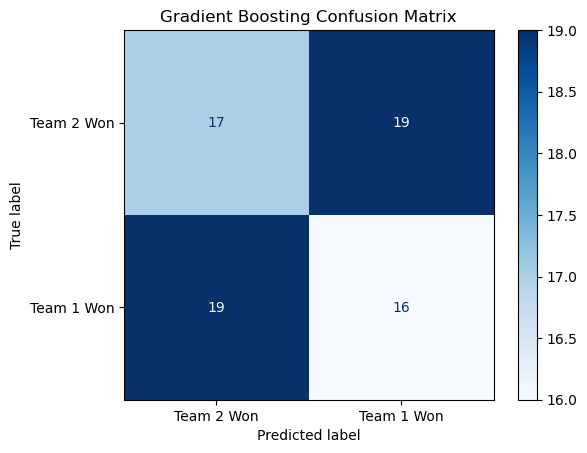

In [288]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Team 2 Won", "Team 1 Won"],
    cmap="Blues"
)

plt.title("Gradient Boosting Confusion Matrix")
plt.show()

              precision    recall  f1-score   support

  Team 2 Won       0.47      0.47      0.47        36
  Team 1 Won       0.46      0.46      0.46        35

    accuracy                           0.46        71
   macro avg       0.46      0.46      0.46        71
weighted avg       0.46      0.46      0.46        71



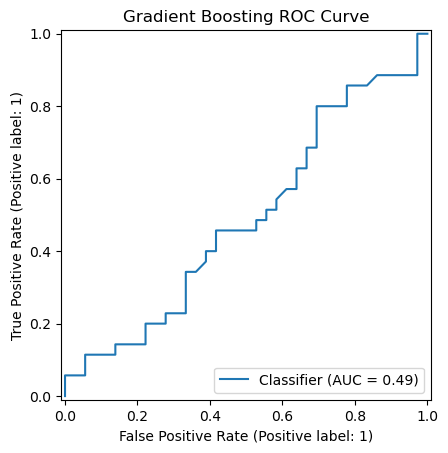

In [289]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Team 2 Won", "Team 1 Won"],
        zero_division=0
    )
)

from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Gradient Boosting ROC Curve")
plt.show()

In [290]:
preprocessor_fitted = final_model.named_steps["preprocessor"]
gb_model = final_model.named_steps["model"]

feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": gb_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
104,numerical__elo_difference,0.228341
109,numerical__matches_played_diff,0.164182
107,numerical__venue_win_rate_diff,0.068119
105,numerical__recent_form_diff,0.059909
80,categorical__team1_Pune Warriors,0.044348
106,numerical__h2h_win_rate_diff,0.043829
95,categorical__team2_Pune Warriors,0.043334
52,categorical__venue_MA Chidambaram Stadium,0.042979
79,categorical__team1_Mumbai Indians,0.036714
94,categorical__team2_Mumbai Indians,0.035065


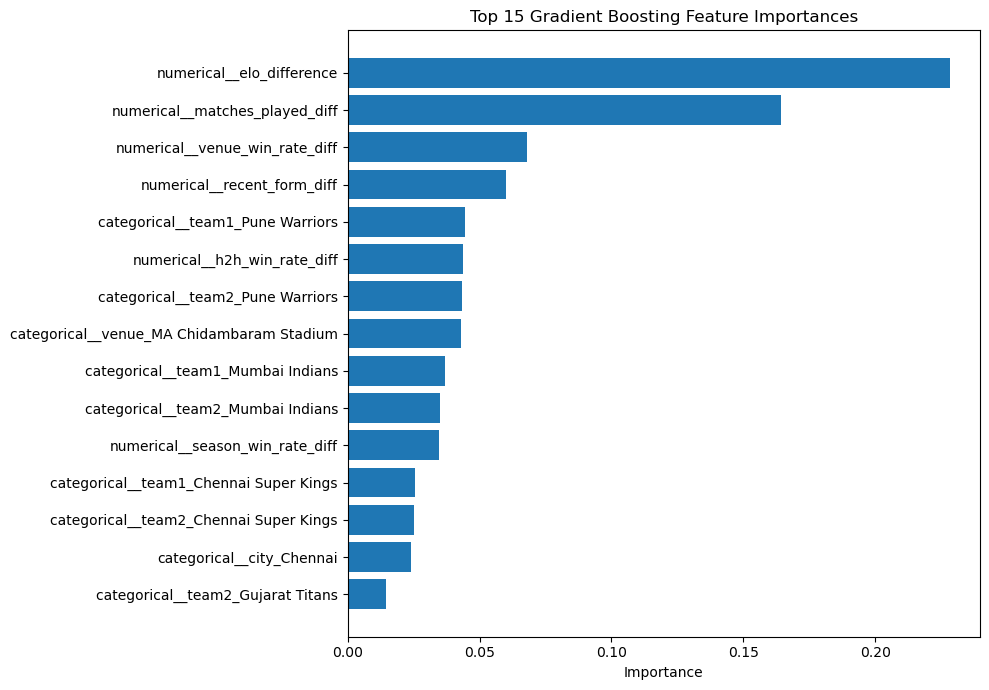

In [291]:
top_features = feature_importance.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Gradient Boosting Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [292]:
prediction_results = test_data[
    ["team1", "team2", "team1_win"]
].copy()

prediction_results["Actual Winner"] = np.where(
    prediction_results["team1_win"] == 1,
    prediction_results["team1"],
    prediction_results["team2"]
)

prediction_results["Predicted Winner"] = np.where(
    y_pred == 1,
    prediction_results["team1"],
    prediction_results["team2"]
)

prediction_results["Team 1 Win Probability"] = y_prob

prediction_results["Correct Prediction"] = (
    prediction_results["Actual Winner"]
    ==
    prediction_results["Predicted Winner"]
)

prediction_results.head(10)

,team1,team2,team1_win,Actual Winner,Predicted Winner,Team 1 Win Probability,Correct Prediction
1019,Royal Challengers Bengaluru,Chennai Super Kings,0,Chennai Super Kings,Chennai Super Kings,0.411908,True
1020,Delhi Capitals,Punjab Kings,0,Punjab Kings,Delhi Capitals,0.516777,False
1021,Kolkata Knight Riders,Sunrisers Hyderabad,1,Kolkata Knight Riders,Kolkata Knight Riders,0.548026,True
1022,Rajasthan Royals,Lucknow Super Giants,1,Rajasthan Royals,Lucknow Super Giants,0.306109,False
1023,Gujarat Titans,Mumbai Indians,1,Gujarat Titans,Gujarat Titans,0.556241,True
1024,Punjab Kings,Royal Challengers Bengaluru,0,Royal Challengers Bengaluru,Royal Challengers Bengaluru,0.483755,True
1025,Chennai Super Kings,Gujarat Titans,1,Chennai Super Kings,Gujarat Titans,0.489271,False
1026,Sunrisers Hyderabad,Mumbai Indians,1,Sunrisers Hyderabad,Mumbai Indians,0.471618,False
1027,Rajasthan Royals,Delhi Capitals,1,Rajasthan Royals,Rajasthan Royals,0.517894,True
1028,Royal Challengers Bengaluru,Kolkata Knight Riders,0,Kolkata Knight Riders,Royal Challengers Bengaluru,0.500346,False


# Module 8: Save the Trained Model

In [293]:
import joblib
import os

os.makedirs("models", exist_ok=True)

final_model = trained_models["Gradient Boosting"]

joblib.dump(
    final_model,
    "models/ipl_gradient_boosting_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [294]:
model_metadata = {
    "feature_columns": feature_columns,
    "categorical_features": categorical_features,
    "numerical_features": numerical_features,
    "teams": sorted(
        set(model_features["team1"]).union(
            set(model_features["team2"])
        )
    ),
    "cities": sorted(model_features["city"].dropna().unique()),
    "venues": sorted(model_features["venue"].dropna().unique()),
    "toss_decisions": sorted(
        model_features["toss_decision"].dropna().unique()
    )
}

joblib.dump(
    model_metadata,
    "models/ipl_model_metadata.pkl"
)

print("Metadata saved successfully.")

Metadata saved successfully.


In [295]:
historical_state = {
    "elo_rating": dict(elo_rating),
    "recent_results": {
        team: list(results)
        for team, results in recent_results.items()
    },
    "h2h_matches": dict(h2h_matches),
    "h2h_wins": {
        key: dict(value)
        for key, value in h2h_wins.items()
    },
    "venue_matches": dict(venue_matches),
    "venue_wins": dict(venue_wins),
    "team_matches": dict(team_matches)
}

joblib.dump(
    historical_state,
    "models/ipl_historical_state.pkl"
)

print("Historical state saved successfully.")

Historical state saved successfully.


In [296]:
print(os.listdir("models"))

['ipl_gradient_boosting_model.pkl', 'ipl_historical_state.pkl', 'ipl_model_metadata.pkl']


In [297]:
loaded_model = joblib.load(
    "models/ipl_gradient_boosting_model.pkl"
)

test_predictions = loaded_model.predict(X_test)

print("Loaded model works successfully.")
print("Number of test predictions:", len(test_predictions))

Loaded model works successfully.
Number of test predictions: 71


# Module 9: IPL 2025 Prediction Engine

In [298]:
import joblib
import pandas as pd
import numpy as np

model = joblib.load(
    "models/ipl_gradient_boosting_model.pkl"
)

metadata = joblib.load(
    "models/ipl_model_metadata.pkl"
)

historical_state = joblib.load(
    "models/ipl_historical_state.pkl"
)

print("Model and supporting files loaded successfully.")

Model and supporting files loaded successfully.


In [299]:
def predict_match_winner(
    team1,
    team2,
    city,
    venue,
    toss_winner,
    toss_decision
):
    if team1 == team2:
        raise ValueError("Team 1 and Team 2 must be different.")

    elo = historical_state["elo_rating"]
    recent = historical_state["recent_results"]
    h2h_matches = historical_state["h2h_matches"]
    h2h_wins = historical_state["h2h_wins"]
    venue_matches = historical_state["venue_matches"]
    venue_wins = historical_state["venue_wins"]
    team_matches = historical_state["team_matches"]

    h2h_key = tuple(sorted([team1, team2]))

    team1_elo = elo.get(team1, 1500)
    team2_elo = elo.get(team2, 1500)

    team1_recent = np.mean(recent.get(team1, [0.5]))
    team2_recent = np.mean(recent.get(team2, [0.5]))

    total_h2h = h2h_matches.get(h2h_key, 0)

    team1_h2h = (
        h2h_wins.get(h2h_key, {}).get(team1, 0) / total_h2h
        if total_h2h else 0.5
    )

    team2_h2h = (
        h2h_wins.get(h2h_key, {}).get(team2, 0) / total_h2h
        if total_h2h else 0.5
    )

    team1_venue_matches = venue_matches.get((team1, venue), 0)
    team2_venue_matches = venue_matches.get((team2, venue), 0)

    team1_venue_rate = (
        venue_wins.get((team1, venue), 0) /
        team1_venue_matches
        if team1_venue_matches else 0.5
    )

    team2_venue_rate = (
        venue_wins.get((team2, venue), 0) /
        team2_venue_matches
        if team2_venue_matches else 0.5
    )

    input_data = pd.DataFrame([{
        "city": city,
        "venue": venue,
        "team1": team1,
        "team2": team2,
        "toss_decision": toss_decision,
        "team1_won_toss": int(toss_winner == team1),

        "elo_difference":
            team1_elo - team2_elo,

        "recent_form_diff":
            team1_recent - team2_recent,

        "h2h_win_rate_diff":
            team1_h2h - team2_h2h,

        "venue_win_rate_diff":
            team1_venue_rate - team2_venue_rate,

        "season_win_rate_diff": 0.0,

        "matches_played_diff":
            team_matches.get(team1, 0) -
            team_matches.get(team2, 0)
    }])

    probability_team1 = model.predict_proba(input_data)[0][1]
    probability_team2 = 1 - probability_team1

    predicted_winner = (
        team1 if probability_team1 >= 0.5 else team2
    )

    return {
        "Predicted Winner": predicted_winner,
        f"{team1} Probability": round(probability_team1 * 100, 2),
        f"{team2} Probability": round(probability_team2 * 100, 2)
    }

prediction = predict_match_winner(
    team1="Mumbai Indians",
    team2="Chennai Super Kings",
    city="Mumbai",
    venue="Wankhede Stadium",
    toss_winner="Mumbai Indians",
    toss_decision="field"
)

prediction

{'Predicted Winner': 'Mumbai Indians',
 'Mumbai Indians Probability': 52.89,
 'Chennai Super Kings Probability': 47.11}

# Module 10: Save the Model for Streamlit

In [300]:
pip install joblib

In [301]:
import joblib
import os 

joblib.dump(
    "Gradient Boosting",
    r"C:\Users\anujm\OneDrive\Documents\Desktop\CricketIQ\models\ipl_gradient_boosting_model.pkl"
)

['C:\\Users\\anujm\\OneDrive\\Documents\\Desktop\\CricketIQ\\models\\ipl_gradient_boosting_model.pkl']

In [302]:
import joblib

historical_state = {
    "elo_rating": dict(elo_rating),
    "recent_results": {
        team: list(results)
        for team, results in recent_results.items()
    },
    "h2h_matches": dict(h2h_matches),
    "h2h_wins": {
        key: dict(value)
        for key, value in h2h_wins.items()
    },
    "venue_matches": dict(venue_matches),
    "venue_wins": dict(venue_wins),
    "team_matches": dict(team_matches)
}

joblib.dump(
    historical_state,
    r"C:\Users\anujm\OneDrive\Documents\Desktop\CricketIQ\models\ipl_historical_state.pkl"
)

['C:\\Users\\anujm\\OneDrive\\Documents\\Desktop\\CricketIQ\\models\\ipl_historical_state.pkl']

In [303]:
import joblib

MODEL_PATH = (
    r"C:\Users\anujm\OneDrive\Documents\Desktop\CricketIQ\models\ipl_gradient_boosting_model.pkl"
)

joblib.dump(final_model, MODEL_PATH)

print("Complete model pipeline saved successfully.")

Complete model pipeline saved successfully.


In [304]:
results_df

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Dummy Classifier,0.507042,0.500000,0.000000,0.000000,0.000000,0.500000
1,Gradient Boosting,0.464789,0.464683,0.457143,0.457143,0.457143,0.490079
2,Random Forest,0.492958,0.492063,0.483871,0.428571,0.454545,0.480159
3,Logistic Regression,0.521127,0.520635,0.515152,0.485714,0.500000,0.466667


In [305]:
gradient_results = (
    results_df[
        results_df["Model"] == "Gradient Boosting"
    ]
    .iloc[0]
)

model_metadata = {
    "model_name": "Gradient Boosting",
    "accuracy": float(gradient_results["Accuracy"]),
    "balanced_accuracy": float(
        gradient_results["Balanced Accuracy"]
    ),
    "precision": float(gradient_results["Precision"]),
    "recall": float(gradient_results["Recall"]),
    "f1_score": float(gradient_results["F1 Score"]),
    "roc_auc": float(gradient_results["ROC-AUC"]),
    "training_seasons": "2008–2023",
    "test_season": 2024,
    "features": feature_columns
}

METADATA_PATH = (
    r"C:\Users\anujm\OneDrive\Documents\Desktop\CricketIQ\models\ipl_model_metadata.pkl"
)

joblib.dump(model_metadata, METADATA_PATH)

print("Model metadata saved successfully.")

Model metadata saved successfully.


In [306]:
import os

MODEL_DIR = (
    r"C:\Users\anujm\OneDrive\Documents\Desktop\CricketIQ\models"
)

print(os.listdir(MODEL_DIR))

['ipl_gradient_boosting_model.pkl', 'ipl_historical_state.pkl', 'ipl_model_metadata.pkl']


In [307]:
loaded_model = joblib.load(MODEL_PATH)

test_predictions = loaded_model.predict(X_test)

print("Pipeline loaded successfully.")
print("Predictions generated:", len(test_predictions))

Pipeline loaded successfully.
Predictions generated: 71
